In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scnn.optimize import optimize
from scnn.regularizers import NeuronGL1


# config
TICKERS: List[str] = ["AAPL", "MSFT", "GOOG"]
DATA_DIR: Path      = Path(".")                 # folder with *_clean.csv files
FILE_TEMPLATE: str  = "{tkr}_2005_2021_clean.csv"

P_OPT: int          = 32
MAX_NEURONS_OPT: int = 512
LAM_GL1_OPT: float   = 1e-3
HUBER_DELTA_OPT: float = 0.1
SPLIT_DATE: str       = "2018-01-02"

PREDICTION_COLS: List[str] = ["log_ret", "sigma20", "TurnUSD"]


# helpers
def mse(y_pred, y) -> float:
    return float(np.mean(np.square(y_pred - y)))


def _unscale(x_scaled: np.ndarray, x_min: float, x_max: float) -> np.ndarray:
    """Inverse of min–max scaling."""
    return x_scaled * (x_max - x_min) + x_min


def prepare_from_csv(
    clean_csv: str | Path,
    p: int = 10,
    split_date: str = "2018-01-02",
    prediction_cols: list[str] | None = None,
) -> Tuple[np.ndarray, np.ndarray,
           Dict[str, Tuple[np.ndarray, np.ndarray, float, float]],
           pd.DatetimeIndex]:
    """
    Read ‘clean’ CSV, build lag features, split train/test, return test index.
    """
    if prediction_cols is None:
        prediction_cols = ["log_ret", "sigma20", "TurnUSD"]

    # robust ingest: skip 2-row header, coerce index to datetime 
    df = pd.read_csv(clean_csv, index_col=0, skiprows=[1]).rename(columns=str.strip)
    df.index = pd.to_datetime(df.index, errors="coerce").normalize()
    df = df[~df.index.isna()]                       # drop rows like “Ticker”

    # min–max scaling 
    def scale_x(x: pd.Series):
        return float(x.min()), float(x.max()), (x - x.min()) / (x.max() - x.min())

    col_stats: Dict[str, Tuple[float, float]] = {}
    for col in prediction_cols:
        col_min, col_max, df[col] = scale_x(df[col])
        col_stats[col] = (col_min, col_max)

    df = df[prediction_cols].dropna()

    # split point 
    split_ts   = pd.to_datetime(split_date)
    split_idx  = df.index.searchsorted(split_ts, side="left")
    if split_idx == len(df):
        raise ValueError(f"{split_date} beyond last row in {clean_csv}")
    relative_split = split_idx - p

    # build lagged feature matrix 
    X, target_data = [], {c: [] for c in prediction_cols}
    for i in range(p, len(df)):
        X.append(df.iloc[i - p:i].values.flatten())
        for c in prediction_cols:
            target_data[c].append(df.iloc[i][c])
    X = np.array(X)

    X_tr, X_te = X[:relative_split], X[relative_split:]
    targets_dict: Dict[str, Tuple[np.ndarray, np.ndarray, float, float]] = {}
    for c in prediction_cols:
        y_full = np.array(target_data[c])
        targets_dict[c] = (
            y_full[:relative_split],          # y_train
            y_full[relative_split:],          # y_test
            *col_stats[c],                    # min, max
        )

    test_index = df.index[p:][relative_split:]     # index for y_test
    return X_tr, X_te, targets_dict, test_index


def train_single_col(
    X_tr, X_te, pred_tuple,
    max_neurons=256, lam_gl1=5e-4, huber_delta=0.1,
    verbose: bool = False, col_name: str = ""
):
    """Fit one SCNN and return train-MSE, test-MSE, model, un-scaled preds."""
    y_tr, y_te, x_min, x_max = pred_tuple
    model, _ = optimize(
        formulation="gated_relu",
        max_neurons=max_neurons,
        X_train=X_tr,
        y_train=y_tr,
        X_test=X_te,
        y_test=y_te,
        bias=True,
        loss_type="huber",
        huber_delta=huber_delta,
        regularizer=NeuronGL1(lam_gl1),
        verbose=verbose,
        device="cpu",
    )
    preds = model(X_te)
    return (
        mse(model(X_tr), y_tr),
        mse(preds, y_te),
        model,
        _unscale(preds.ravel(), x_min, x_max),
    )


# Multi-ticker driver
def train_and_collect() -> None:
    """
    Train SCNNs for each ticker/target and save all OOS predictions.
    """
    wide_frames: List[pd.DataFrame] = []

    for tkr in TICKERS:
        csv_path = DATA_DIR / FILE_TEMPLATE.format(tkr=tkr)
        X_tr, X_te, targets, idx_test = prepare_from_csv(
            csv_path,
            p=P_OPT,
            split_date=SPLIT_DATE,
            prediction_cols=PREDICTION_COLS,
        )

        cols_out: Dict[str, np.ndarray] = {}
        for col, tup in targets.items():
            tr_mse, te_mse, mdl, preds_unscaled = train_single_col(
                X_tr, X_te, tup,
                max_neurons=MAX_NEURONS_OPT,
                lam_gl1=LAM_GL1_OPT,
                huber_delta=HUBER_DELTA_OPT,
                col_name=f"{tkr}_{col}",
            )
            print(f"{tkr} | {col:8s}  train {tr_mse:8.4f}  test {te_mse:8.4f}")
            cols_out[f"{tkr}_{col}"] = preds_unscaled

        wide_frames.append(pd.DataFrame(cols_out, index=idx_test))

    # combine & save 
    combined = pd.concat(wide_frames, axis=1).sort_index()
    out_path = Path("oos_predictions_2018on.csv")
    combined.to_csv(out_path)
    print(f"\n✔  All predictions written to {out_path.resolve()}\n")


if __name__ == "__main__":
    train_and_collect()

/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_2596/2114524877.py:54: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce").normalize()


AAPL | log_ret   train   0.0140  test   0.0467
AAPL | sigma20   train   0.0238  test   0.0283
AAPL | TurnUSD   train   0.0082  test   0.0294


/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_2596/2114524877.py:54: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce").normalize()


MSFT | log_ret   train   0.0057  test   0.1587
MSFT | sigma20   train   0.0213  test   0.0420
MSFT | TurnUSD   train   0.0028  test   0.0508


/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_2596/2114524877.py:54: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce").normalize()


GOOG | log_ret   train   0.0061  test   0.0061
GOOG | sigma20   train   0.0403  test   0.0319
GOOG | TurnUSD   train   0.0086  test   0.0062

✔  All predictions written to /Users/aqibsyed/Documents/Spring 2025/EE 364b/Final Project/scnn/scnn_zahedi_syed/notebooks/oos_predictions_2018on.csv



## original plotting code

/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_1776/1053870601.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df.index, errors="coerce")
/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_1776/1053870601.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df.index, errors="coerce")
/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_1776/1053870601.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df.index, errors="coerce")
/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_1776/105387

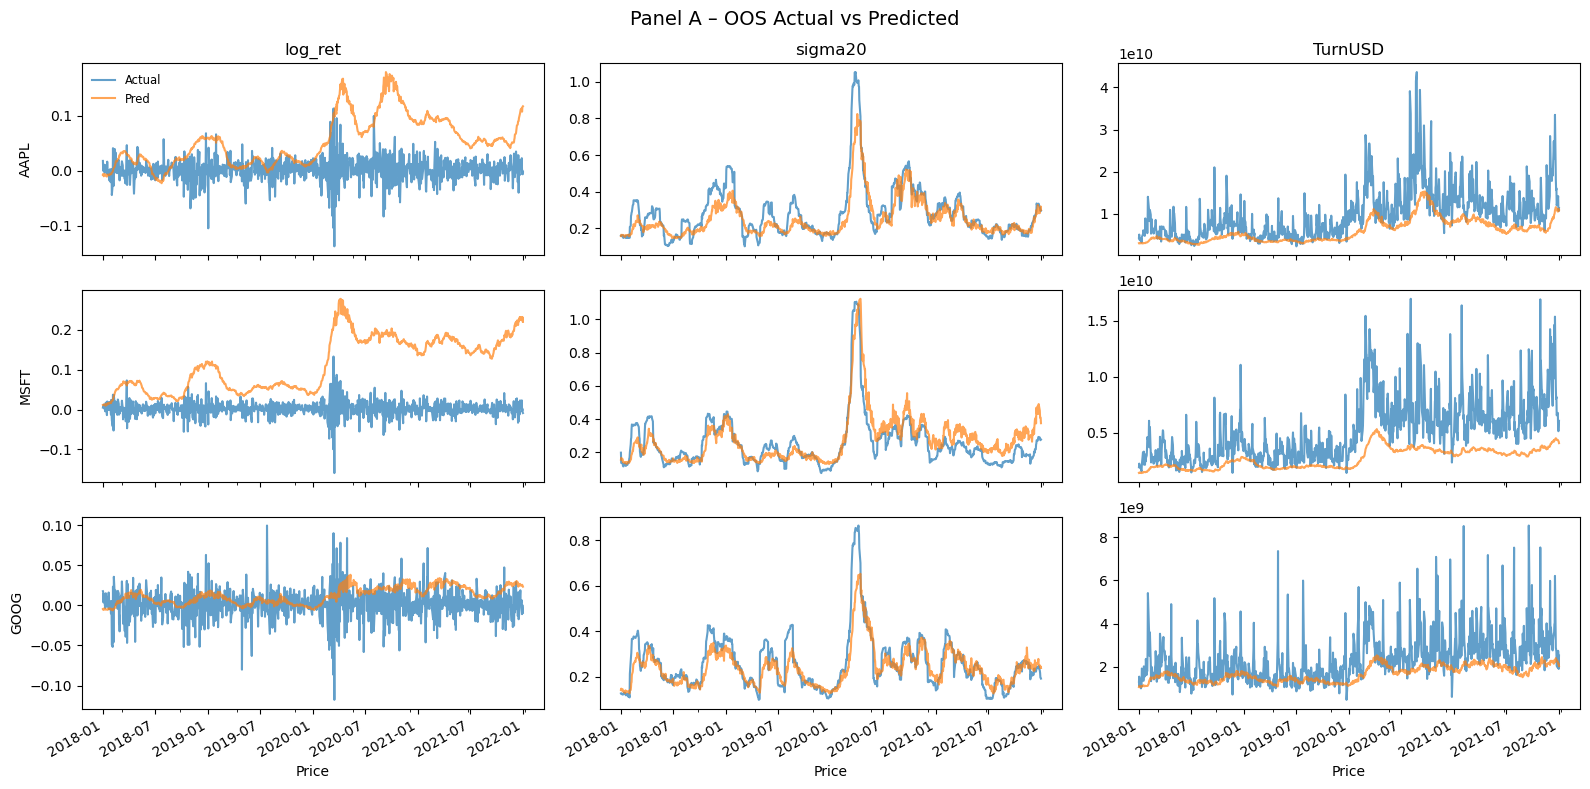

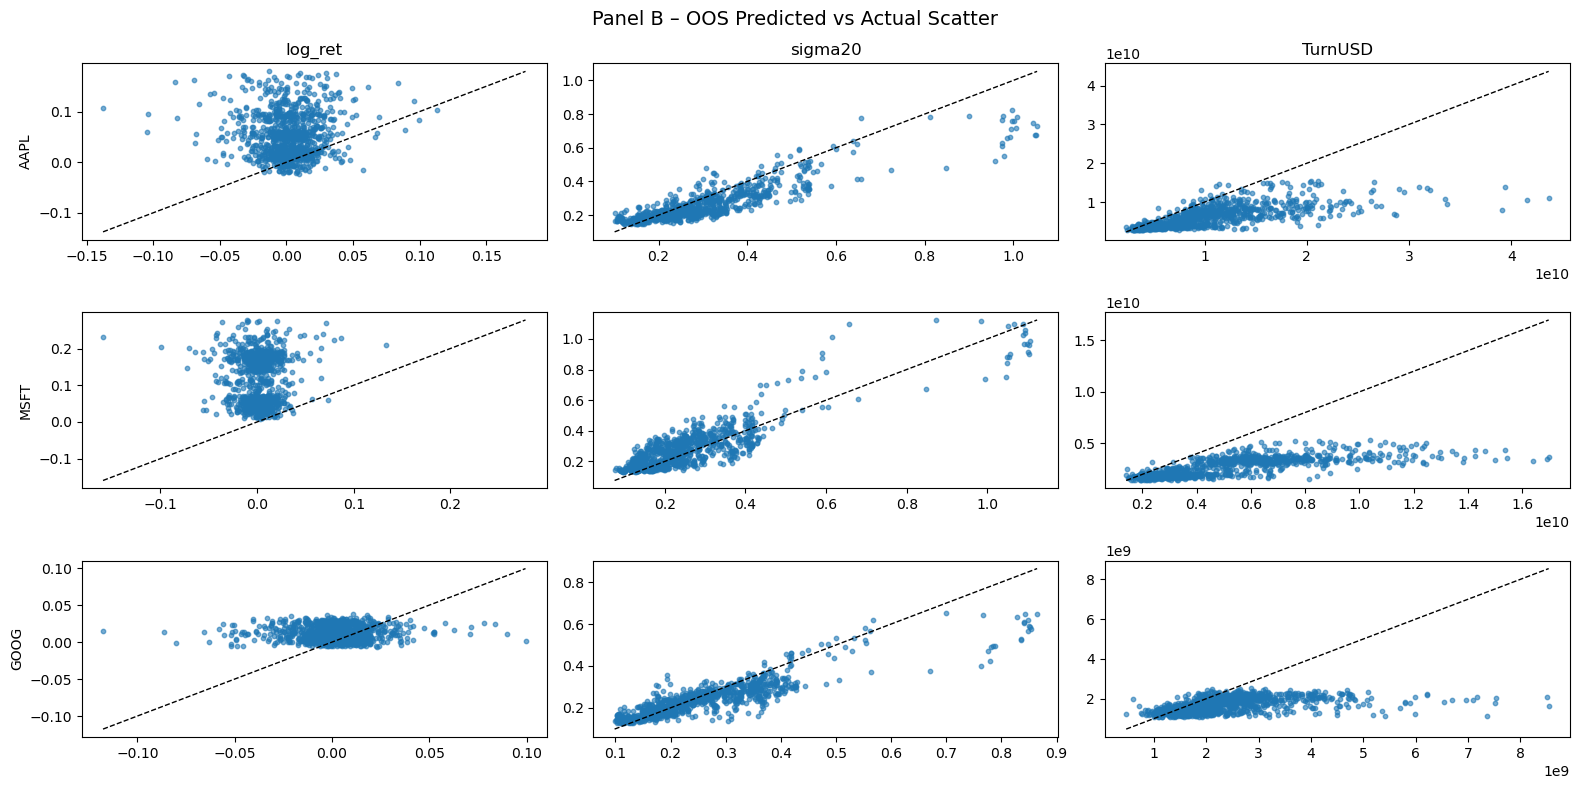

In [1]:
# ───────── config ─────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

TICKERS        = ["AAPL", "MSFT", "GOOG"]
PRED_COLS      = ["log_ret", "sigma20", "TurnUSD"]
SPLIT_DATE     = "2018-01-02"

PRED_FILE      = Path("oos_predictions_2018on.csv")       # created earlier
DATA_DIR       = Path(".")                                # where *_clean.csv live
CLEAN_TMPL     = "{tkr}_2005_2021_clean.csv"

# ───────── load predictions ───────────────────────────────────────────
pred_df = (
    pd.read_csv(PRED_FILE, index_col=0, parse_dates=True)
    .sort_index()
)
# ensure index normalised to midnight
pred_df.index = pred_df.index.normalize()

# ───────── helper: read actuals for a single ticker ───────────────────
def actual_series(ticker: str, col: str) -> pd.Series:
    path = DATA_DIR / CLEAN_TMPL.format(tkr=ticker)
    df = (
        pd.read_csv(path, index_col=0, skiprows=[1])
        .rename(columns=str.strip)
    )
    df.index = (
        pd.to_datetime(df.index, errors="coerce")
        .normalize()
    )
    return (
        df.loc[df.index >= SPLIT_DATE, col]
        .sort_index()
        .rename(f"{ticker}_{col}")
    )

# ───────── collect metrics & build joint table ───────────────────────
metrics = []          # rows: (Ticker, Target, MSE, MAE, R2)
joint   = []          # list of DataFrames to concat horizontally

for tkr in TICKERS:
    for col in PRED_COLS:
        col_name = f"{tkr}_{col}"
        y_true = actual_series(tkr, col)
        y_pred = pred_df[col_name].dropna()

        # align indices (inner join)
        y_true, y_pred = y_true.align(y_pred, join="inner")
        joint.append(pd.DataFrame({
            f"{col_name}_true": y_true,
            f"{col_name}_pred": y_pred,
        }))

        # error stats
        mse_val = mean_squared_error(y_true, y_pred)
        mae_val = mean_absolute_error(y_true, y_pred)
        r2_val  = r2_score(y_true, y_pred)
        metrics.append((tkr, col, mse_val, mae_val, r2_val))

metrics_df = pd.DataFrame(
    metrics, columns=["Ticker", "Target", "MSE", "MAE", "R2"]
).set_index(["Ticker", "Target"])

display(metrics_df.style.format({"MSE": "{:.4e}", "MAE": "{:.4e}", "R2": "{:.3f}"}))

merged = pd.concat(joint, axis=1).sort_index()

# ───────── Panel A: time-series overlay ───────────────────────────────
fig_ts, axes = plt.subplots(
    len(TICKERS), len(PRED_COLS), figsize=(16, 8), sharex=True
)
for i, tkr in enumerate(TICKERS):
    for j, col in enumerate(PRED_COLS):
        ax = axes[i, j] if axes.ndim == 2 else axes[max(i, j)]
        name = f"{tkr}_{col}"
        merged[f"{name}_true"].plot(ax=ax, label="Actual", alpha=0.7)
        merged[f"{name}_pred"].plot(ax=ax, label="Pred", alpha=0.7)

        if i == 0:
            ax.set_title(col)
        if j == 0:
            ax.set_ylabel(tkr)

        if i == 0 and j == 0:
            ax.legend(frameon=False, fontsize="small")

fig_ts.suptitle("Panel A – OOS Actual vs Predicted", y=0.98, fontsize=14)
fig_ts.tight_layout()

# ───────── Panel B: scatter, one subplot per ticker-target ────────────
fig_sc, axes_sc = plt.subplots(
    len(TICKERS), len(PRED_COLS), figsize=(16, 8), sharex=False, sharey=False
)
for i, tkr in enumerate(TICKERS):
    for j, col in enumerate(PRED_COLS):
        ax = axes_sc[i, j]
        name = f"{tkr}_{col}"
        x = merged[f"{name}_true"]
        y = merged[f"{name}_pred"]

        ax.scatter(x, y, s=10, alpha=0.6)
        lims = [min(x.min(), y.min()), max(x.max(), y.max())]
        ax.plot(lims, lims, "k--", lw=1)          # 45° line

        if i == 0:
            ax.set_title(col)
        if j == 0:
            ax.set_ylabel(tkr)

fig_sc.suptitle("Panel B – OOS Predicted vs Actual Scatter", y=0.98, fontsize=14)
fig_sc.tight_layout()

## modified plotting code-much nicer formatting

metrics table: oos_error_table.tex


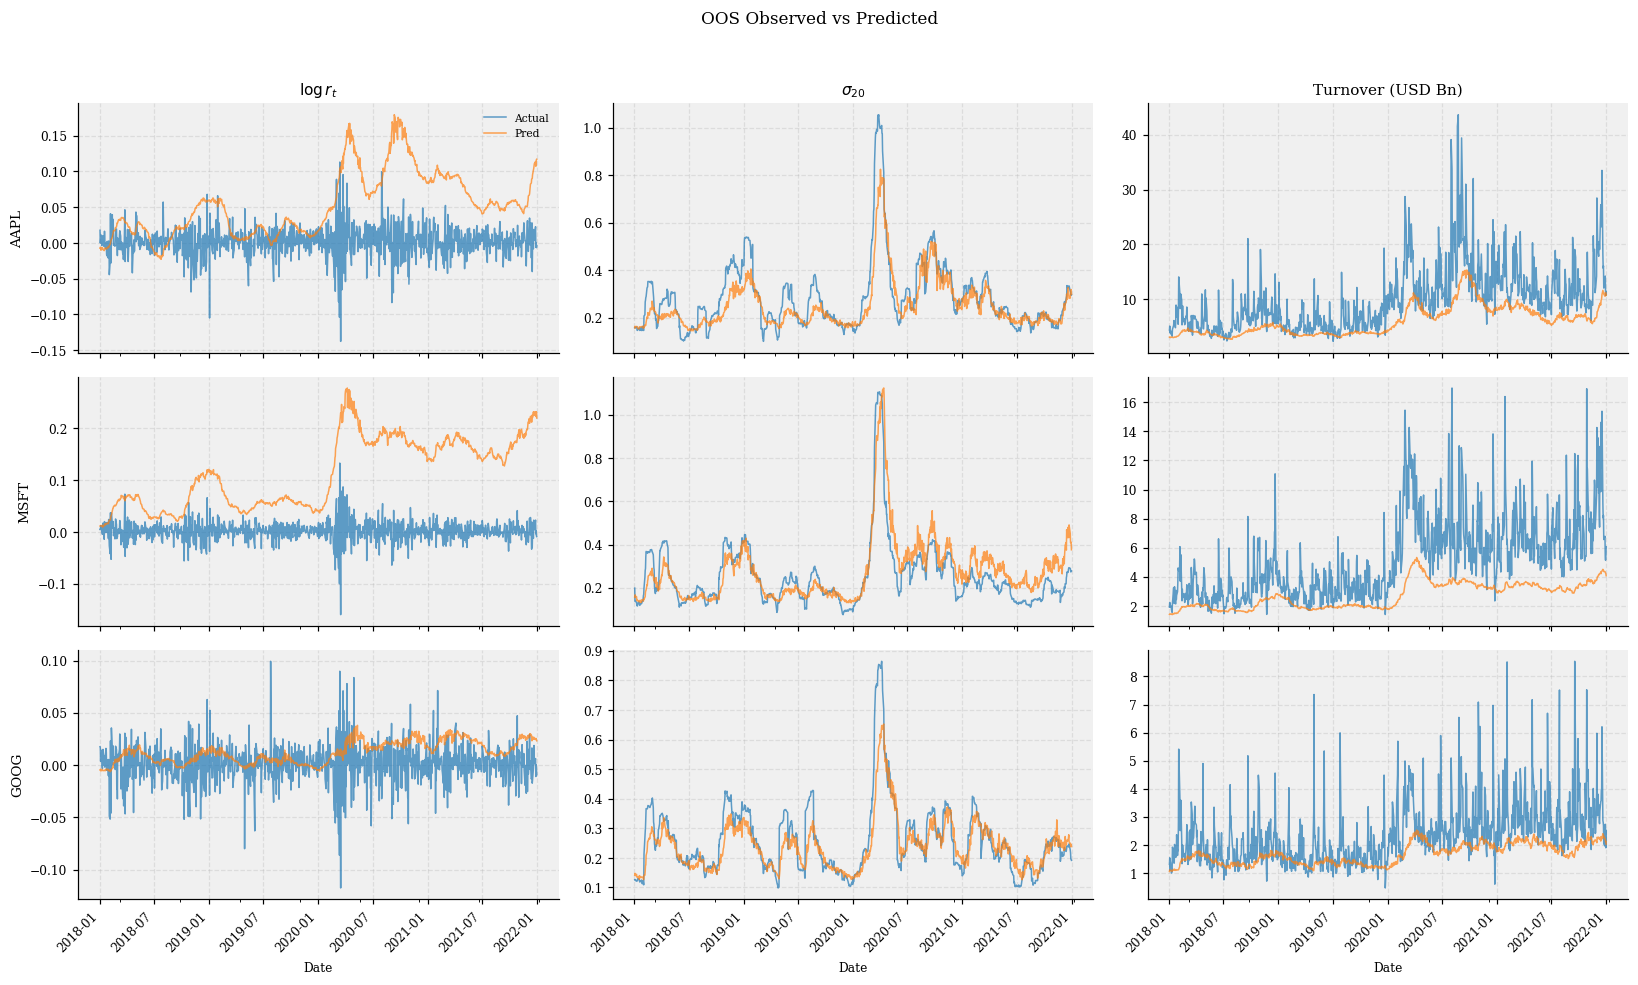

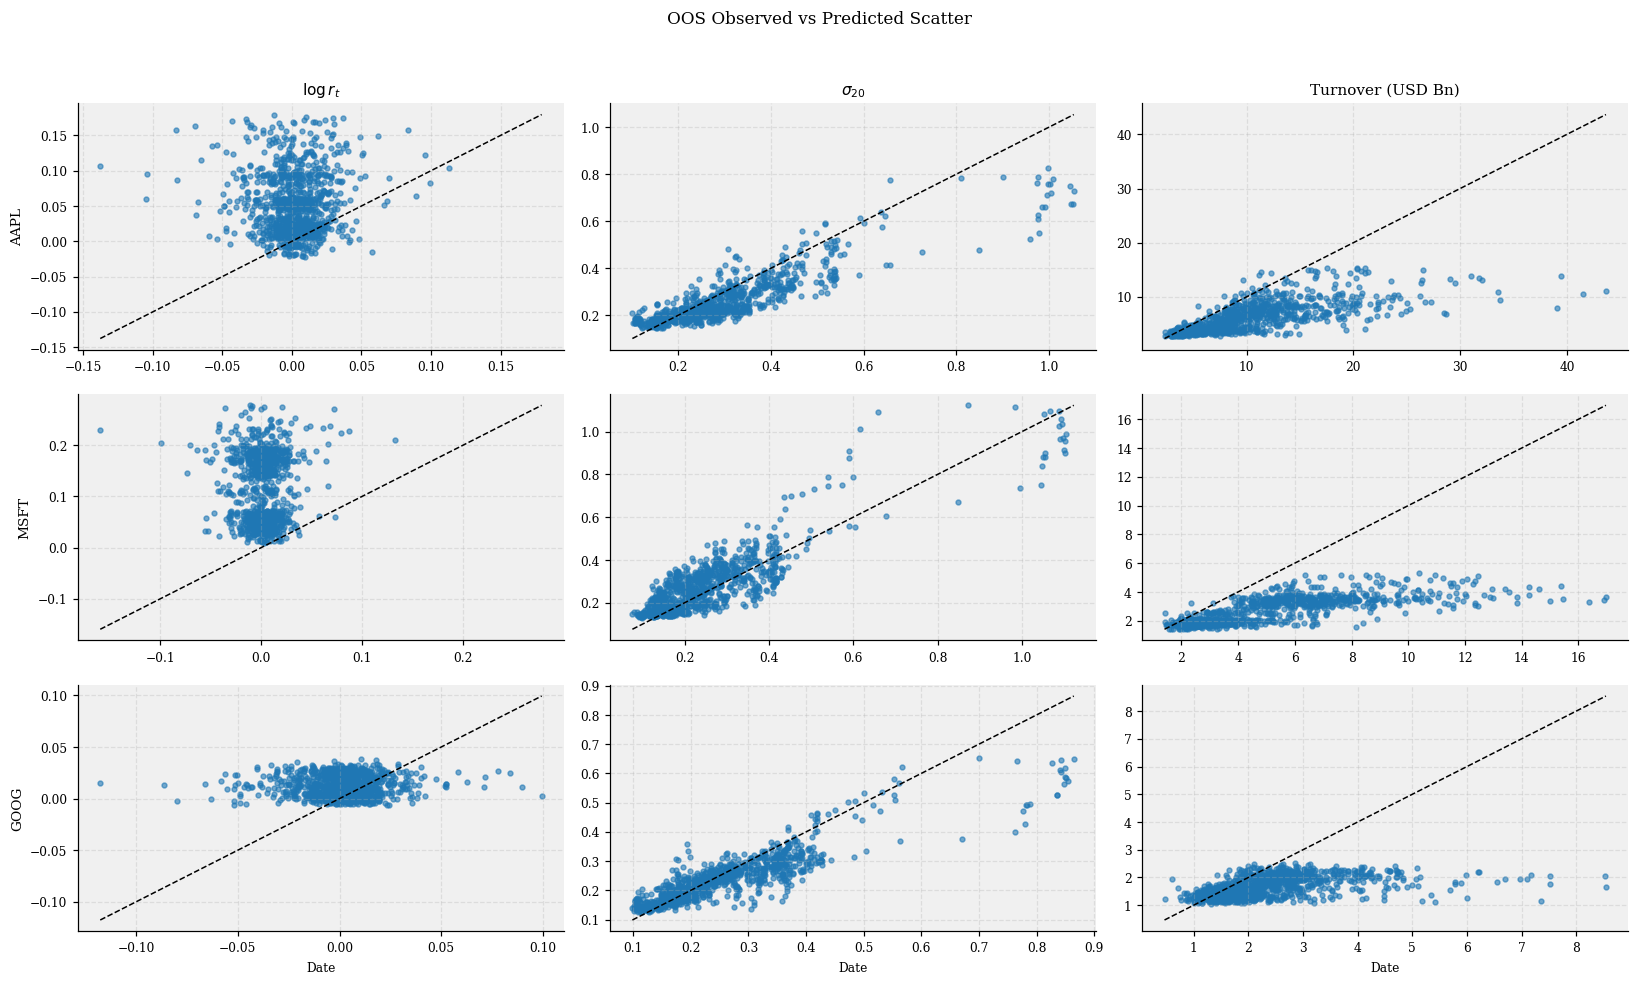

In [1]:
from pathlib import Path
import shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

TICKERS      = ["AAPL", "MSFT", "GOOG"]
PRED_COLS    = ["log_ret", "sigma20", "TurnUSD"]
SPLIT_DATE   = "2018-01-02"

PRED_FILE    = Path("oos_predictions_2018on.csv")      # forecasts
DATA_DIR     = Path(".")                               # *_clean.csv live here
CLEAN_TMPL   = "{tkr}_2005_2021_clean.csv"

# scale TurnUSD to billions for readability
SCALE        = {"log_ret": 1.0, "sigma20": 1.0, "TurnUSD": 1e9}

#matplotlib global style 
HAS_LATEX  = shutil.which("latex") is not None
DEFAULT_SERIF = "DejaVu Serif"          # ships with Matplotlib

mpl.rcParams.update({
    "text.usetex": HAS_LATEX,
    "font.family": "serif",
    "font.serif": ["cmr10"] if HAS_LATEX else [DEFAULT_SERIF],
    "axes.titlesize": 10,  "axes.labelsize": 9,
    "xtick.labelsize": 8,  "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": .8,   "lines.linewidth": 1.0,
    "legend.frameon": False, "figure.dpi": 110,
})
warnings.filterwarnings("ignore",
        message="findfont: Generic family 'serif' not found*")

TEX_LBL = {
    "log_ret":  r"$\log r_t$",
    "sigma20":  r"$\sigma_{20}$",
    "TurnUSD":  r"\text{Turnover (USD Bn)}" if HAS_LATEX else "Turnover (USD Bn)",
}

# load predictions
pred_df = (pd.read_csv(PRED_FILE, index_col=0, parse_dates=True)
             .sort_index())
pred_df.index = pred_df.index.normalize()      # midnight timestamps

# helper: read scaled actual series
def actual_series(ticker: str, col: str) -> pd.Series:
    df = (pd.read_csv(DATA_DIR / CLEAN_TMPL.format(tkr=ticker),
                      index_col=0, skiprows=[1])
            .rename(columns=str.strip))
    df.index = pd.to_datetime(df.index, format="%Y-%m-%d",
                              errors="coerce").normalize()
    return df.loc[df.index >= SPLIT_DATE, col].sort_index() / SCALE[col]

# build metrics & table 
metrics, dfs = [], []
for tkr in TICKERS:
    for col in PRED_COLS:
        name   = f"{tkr}_{col}"
        y_true = actual_series(tkr, col)
        y_pred = pred_df[name] / SCALE[col]
        y_true, y_pred = y_true.align(y_pred, join="inner")

        dfs.append(pd.DataFrame({f"{name}_true": y_true,
                                 f"{name}_pred": y_pred}))
        metrics.append([tkr, col,
                        mean_squared_error(y_true, y_pred),
                        mean_absolute_error(y_true, y_pred),
                        r2_score(y_true, y_pred)])

metrics_df = (pd.DataFrame(metrics,
                           columns=["Ticker", "Target", "MSE", "MAE", "R2"])
               .set_index(["Ticker", "Target"]))
display(metrics_df.style.format({"MSE":"{:.4e}","MAE":"{:.4e}","R2":"{:.3f}"}))
metrics_df.to_latex("oos_error_table.tex", float_format="%.4e")
print("metrics table: oos_error_table.tex")

merged = pd.concat(dfs, axis=1).sort_index()

# styling helper 
def style_axes(ax, is_bottom: bool):
    ax.set_facecolor("#f0f0f0")
    ax.grid(True, which="major", axis="both",
            linestyle="--", alpha=0.3)      # vertical & horizontal
    ax.tick_params(labelsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if is_bottom:
        ax.set_xlabel("Date", fontsize=8)

# Panel A – overlay 
fig_ts, axes = plt.subplots(len(TICKERS), len(PRED_COLS),
                            figsize=(5*len(PRED_COLS), 3*len(TICKERS)),
                            sharex=True)
for i, tkr in enumerate(TICKERS):
    for j, col in enumerate(PRED_COLS):
        ax   = axes[i, j]
        name = f"{tkr}_{col}"
        merged[f"{name}_true"].plot(ax=ax, label="Actual", alpha=0.7)
        merged[f"{name}_pred"].plot(ax=ax, label="Pred",   alpha=0.7)
        if i == 0: ax.set_title(TEX_LBL[col])
        if j == 0: ax.set_ylabel(tkr)
        if i == 0 and j == 0: ax.legend(fontsize=7)
        style_axes(ax, is_bottom=(i == len(TICKERS)-1))

fig_ts.suptitle("OOS Observed vs Predicted", y=0.99, fontsize=11)
fig_ts.autofmt_xdate(rotation=45)
fig_ts.tight_layout(rect=[0, 0, 1, 0.97])

# Panel B – scatter 
fig_sc, axes_sc = plt.subplots(len(TICKERS), len(PRED_COLS),
                               figsize=(5*len(PRED_COLS), 3*len(TICKERS)))
for i, tkr in enumerate(TICKERS):
    for j, col in enumerate(PRED_COLS):
        ax   = axes_sc[i, j]
        name = f"{tkr}_{col}"
        x = merged[f"{name}_true"];  y = merged[f"{name}_pred"]
        ax.scatter(x, y, s=10, alpha=0.6)
        lims = [min(x.min(), y.min()), max(x.max(), y.max())]
        ax.plot(lims, lims, "k--", lw=1)
        if i == 0: ax.set_title(TEX_LBL[col])
        if j == 0: ax.set_ylabel(tkr)
        style_axes(ax, is_bottom=(i == len(TICKERS)-1))

fig_sc.suptitle("OOS Observed vs Predicted Scatter", y=0.99, fontsize=11)
fig_sc.tight_layout(rect=[0, 0, 1, 0.97])

## Seeing if our approach beats baseline as suggested by Jones, Kaul and Lipson (1994)

In [2]:
# oos_volume_R2_benchmark.py  -----------------------------------------
from pathlib import Path
import shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# statsmodels for the AR(1) benchmark
from statsmodels.tsa.ar_model import AutoReg

# ─── 1. configuration ────────────────────────────────────────────────
TICKERS      = ["AAPL", "MSFT", "GOOG"]
PRED_COLS    = ["log_ret", "sigma20", "TurnUSD"]
SPLIT_DATE   = "2018-01-02"

PRED_FILE    = Path("oos_predictions_2018on.csv")
DATA_DIR     = Path(".")
CLEAN_TMPL   = "{tkr}_2005_2021_clean.csv"

SCALE        = {"log_ret": 1.0, "sigma20": 1.0, "TurnUSD": 1e9}   # TurnUSD → bn

# ─── 2. global Matplotlib style (unchanged) ──────────────────────────
HAS_LATEX = shutil.which("latex") is not None
mpl.rcParams.update({
    "text.usetex": HAS_LATEX,
    "font.family": "serif",
    "font.serif": ["cmr10"] if HAS_LATEX else ["DejaVu Serif"],
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8,  "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": .8, "lines.linewidth": 1.0,
    "legend.frameon": False, "figure.dpi": 110,
})
warnings.filterwarnings("ignore",
        message="findfont: Generic family 'serif' not found*")

# ─── 3. load SCNN predictions ────────────────────────────────────────
pred_df = (pd.read_csv(PRED_FILE, index_col=0, parse_dates=True)
             .sort_index())
pred_df.index = pred_df.index.normalize()

# helper: load *full* TurnUSD series, then split and scale
def load_turnusd(ticker: str) -> pd.Series:
    df = (pd.read_csv(DATA_DIR / CLEAN_TMPL.format(tkr=ticker),
                      index_col=0, skiprows=[1])
            .rename(columns=str.strip))
    df.index = pd.to_datetime(df.index, errors="coerce").normalize()
    return df["TurnUSD"] / SCALE["TurnUSD"]

# ─── 4. build SCNN metrics (as before) ───────────────────────────────
metrics, dfs = [], []
for tkr in TICKERS:
    for col in PRED_COLS:
        name   = f"{tkr}_{col}"
        y_true = load_turnusd(tkr) if col == "TurnUSD" else None
        if col != "TurnUSD":
            # for log_ret and sigma20 reuse old helper
            df = pd.read_csv(DATA_DIR / CLEAN_TMPL.format(tkr=tkr),
                             index_col=0, skiprows=[1]).rename(columns=str.strip)
            df.index = pd.to_datetime(df.index, errors="coerce").normalize()
            y_true = df.loc[df.index >= SPLIT_DATE, col] / SCALE[col]

        y_pred = pred_df[name] / SCALE[col]
        y_true, y_pred = y_true.align(y_pred, join="inner")

        dfs.append(pd.DataFrame({f"{name}_true": y_true,
                                 f"{name}_pred": y_pred}))
        metrics.append([tkr, col,
                        mean_squared_error(y_true, y_pred),
                        mean_absolute_error(y_true, y_pred),
                        r2_score(y_true, y_pred)])

metrics_df = (pd.DataFrame(metrics,
                           columns=["Ticker", "Target", "MSE", "MAE", "R2"])
               .set_index(["Ticker", "Target"]))

# keep TurnUSD rows for comparison
scnn_r2 = metrics_df.xs("TurnUSD", level="Target")["R2"]

ar_records = []
for tkr in TICKERS:
    full  = load_turnusd(tkr).dropna()
    train = full.loc[full.index < SPLIT_DATE]
    test  = full.loc[full.index >= SPLIT_DATE]

    # statsmodels AutoReg re-indexes internally (0…n-1)
    ar1 = AutoReg(train, lags=1, old_names=False).fit()

    # predict by *position*: start=len(train) … len(train)+len(test)-1
    preds = ar1.predict(start=len(train),
                        end=len(train)+len(test)-1)

    preds.index = test.index              # give original dates back
    y_test, y_pred = test.align(preds, join="inner")
    ar_records.append([tkr, r2_score(y_test, y_pred)])

ar1_r2 = pd.DataFrame(ar_records,
                      columns=["Ticker", "AR(1) R2"]).set_index("Ticker")

# ─── 6. SCNN vs AR(1) comparison table (styled) ──────────────────────
scnn_r2 = metrics_df.xs("TurnUSD", level="Target")[["R2"]]
comparison = scnn_r2.join(ar1_r2).rename(columns={"R2": "SCNN R2"})

display(comparison.style.format("{:.3f}"))
comparison.to_latex("turnusd_r2_comparison.tex", float_format="%.3f")
print("✔  R² comparison table  →  turnusd_r2_comparison.tex")

print(
    "\nLiterature baseline: daily volume AR(1) ≈ 0.60 (Jones, Kaul & Lipson 1994)"
)

/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_1313/3900790648.py:63: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce").normalize()
/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_1313/3900790648.py:63: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce").normalize()
/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_1313/3900790648.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce").normalize()
/

,SCNN R2,AR(1) R2
Ticker,,
AAPL,0.002,-0.694
MSFT,-0.400,-1.613
GOOG,-0.193,-0.111


✔  R² comparison table  →  turnusd_r2_comparison.tex

Literature baseline: daily volume AR(1) ≈ 0.60 (Jones, Kaul & Lipson 1994)


In [4]:
! pip install pandas_market_calendars

In [1]:
# rich_volume_scnn.py  -----------------------------------------------
from __future__ import annotations
from pathlib import Path
import warnings, math, datetime as dt

import numpy as np
import pandas as pd
import yfinance as yf
import pandas_market_calendars as mcal
from sklearn.metrics import r2_score

from scnn.optimize import optimize
from scnn.regularizers import NeuronGL1

# ─── 1. configuration ────────────────────────────────────────────────
TICKERS       = ["AAPL", "MSFT", "GOOG"]
START         = "2005-01-03"
END           = "2022-01-01"
SPLIT_DATE    = "2018-01-02"
AR_LAGS       = 10
MAX_NEURONS   = 800
LAM_GL1       = 1e-3
VOL_WINDOW    = 20                     # for rolling σ of returns

# ─── 2. helper functions ─────────────────────────────────────────────
def download_eod(tkr: str) -> pd.DataFrame:
    return yf.download(tkr, start=START, end=END,
                       progress=False, auto_adjust=False)

def parkinson_sigma(df: pd.DataFrame) -> pd.Series:
    hl_term = (np.log(df["High"]/df["Low"]))**2
    return np.sqrt(hl_term.rolling(2).sum() / (4*math.log(2)))  # annualised later

def option_expiry_index(index: pd.DatetimeIndex) -> pd.Series:
    # third Friday of each month
    expiries = pd.Series(False, index=index)
    third_friday = (pd.date_range(index.min(), index.max(), freq="WOM-3FRI"))
    expiries.loc[index.intersection(third_friday)] = True
    return expiries

def build_features(df: pd.DataFrame, vix: pd.Series, spy_vol: pd.Series,
                   ticker_id: int) -> tuple[pd.DataFrame, pd.Series]:
    df = df.copy()
    df["log_ret"] = np.log(df["Adj Close"]).diff()
    df["turn"]    = df["Adj Close"] * df["Volume"] / 1e9   # dollars → bn
    df["log_turn"] = np.log(df["turn"]).replace(-np.inf, np.nan)

    # AR lags of log-turnover
    for k in range(1, AR_LAGS+1):
        df[f"lag_turn_{k}"] = df["log_turn"].shift(k)

    # intraday Parkinson σ (annualised)
    df["sigma_hl"] = parkinson_sigma(df) * np.sqrt(252)

    # abs / signed returns
    df["abs_ret"]  = df["log_ret"].abs()
    df["sign_ret"] = df["log_ret"]

    # calendar features
    df["dow"]         = df.index.dayofweek          # 0=Mon
    for d in range(5):
        df[f"dow_{d}"] = (df["dow"] == d).astype(int)
    cal = mcal.get_calendar("NYSE")
    nyse_sched = cal.schedule(start_date=df.index.min(),
                              end_date=df.index.max())
    eom = nyse_sched.index.to_series().groupby(
        nyse_sched.index.to_period("M")).last()
    df["month_end"]    = df.index.isin(eom.values).astype(int)
    df["opt_exp"]      = option_expiry_index(df.index).astype(int)

    # market-wide drivers (lag-1)
    df["vix_lag1"]     = vix.shift(1)
    df["spyvol_lag1"]  = spy_vol.shift(1)

    # ticker ID (one-hot not needed for SCNN)
    df["ticker_id"]    = ticker_id

    # target = next-day *log-turnover*
    y = df["log_turn"].shift(-1)

    X = df.drop(columns=["turn","log_turn","log_ret","Volume","Close",
                         "Adj Close","High","Low","Open","dow"])

    return X.dropna(), y.loc[X.index]

# ─── 3. pull data & assemble pooled matrix ───────────────────────────
vix_df  = download_eod("^VIX")
spy_df  = download_eod("SPY")
vix     = vix_df["Adj Close"].pct_change()         # daily Δ VIX
spy_vol = spy_df["Volume"] / 1e9                   # SPY volume (bn)

Xs, ys = [], []
for i, tkr in enumerate(TICKERS):
    raw = download_eod(tkr)
    X_i, y_i = build_features(raw, vix, spy_vol, i)
    Xs.append(X_i); ys.append(y_i)

X_all = pd.concat(Xs).sort_index()
y_all = pd.concat(ys).sort_index()
common_idx = X_all.index.intersection(y_all.index)
X_all, y_all = X_all.loc[common_idx], y_all.loc[common_idx]

# ─── 4. split train / test & train pooled SCNN ───────────────────────
mask_train = X_all.index < SPLIT_DATE
X_tr, y_tr = X_all[mask_train].to_numpy(np.float32), y_all[mask_train].to_numpy(np.float32).reshape(-1,1)
X_te, y_te = X_all[~mask_train].to_numpy(np.float32), y_all[~mask_train].to_numpy(np.float32).reshape(-1,1)

model, _ = optimize(
    formulation="gated_relu",
    max_neurons=MAX_NEURONS,
    X_train=X_tr,
    y_train=y_tr,
    X_test=X_te,
    y_test=y_te,
    loss_type="huber",
    huber_delta=1.0,
    regularizer=NeuronGL1(LAM_GL1),
    verbose=True,
    device="cpu",
)

# ─── 5. evaluate R² per ticker on OOS window ─────────────────────────
# ─── 5. evaluate R² per ticker on OOS window (NaN-safe) ──────────────
preds = pd.Series(model(X_te).ravel(), index=X_all.index[~mask_train])

results = []
for i, tkr in enumerate(TICKERS):
    test_idx = X_all.index[(~mask_train) & (X_all["ticker_id"] == i)]

    y_true_i = y_all.loc[test_idx]
    y_pred_i = preds.loc[test_idx]

    # drop rows where either side is NaN
    good = (~y_true_i.isna()) & (~y_pred_i.isna())
    if good.sum() < 2:
        warnings.warn(f"{tkr}: not enough non-NaN points; R² set to NaN.")
        r2 = np.nan
    else:
        r2 = r2_score(y_true_i[good], y_pred_i[good])

    results.append([tkr, r2])

r2_df = (pd.DataFrame(results, columns=["Ticker", "SCNN R2"])
           .set_index("Ticker"))
print("\nOut-of-sample R² on log-turnover (bn USD)\n")
print(r2_df.to_string(float_format="{:.3f}".format))

INFO:scnn:Pre-Optimization Metrics: Train Set objective: 0.4018498361110687, Train Set grad_norm: 0.04870949685573578, 


fista:   0%|          | 0/10000 [00:00<?, ?it/s]

Train Set objective: 0.4018498361110687, Train Set grad_norm: 0.04870949685573578, 
Train Set objective: 0.2680346179215377, Train Set grad_norm: 1.989923550489453e-06, 


INFO:scnn:Termination criterion satisfied at iteration 33/10000. Exiting optimization loop.
INFO:scnn:Post-Optimization Metrics: Train Set objective: 0.2671386697226197, Train Set grad_norm: 9.412105625479784e-07, 



Out-of-sample R² on log-turnover (bn USD)

        SCNN R2
Ticker         
AAPL     -0.943
MSFT     -0.943
GOOG     -0.943


INFO:scnn:Pre-Optimization Metrics: Train Set objective: 0.4018498361110687, Train Set grad_norm: 0.04870948940515518, 


fista:   0%|          | 0/10000 [00:00<?, ?it/s]

Train Set objective: 0.4018498361110687, Train Set grad_norm: 0.04870948940515518, 
Train Set objective: 0.26803902505823723, Train Set grad_norm: 2.0880281852807713e-06, 


INFO:scnn:Termination criterion satisfied at iteration 33/10000. Exiting optimization loop.
INFO:scnn:Post-Optimization Metrics: Train Set objective: 0.26713851178317444, Train Set grad_norm: 9.63465075233635e-07, 



--- alignment check (first 3 test rows) ---
              y_test  lag_turn_1
Date                            
2018-01-02  0.432344    1.418379
2018-01-02  1.562855   -0.078716
2018-01-02  0.730941    0.390515


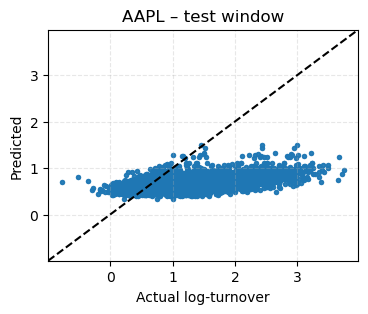


Out-of-sample R² on log-turnover (bn USD)

AAPL: R² = -0.843
MSFT: R² = -0.951
GOOG: R² = -1.089


In [1]:
# rich_turnover_scnn_diagnostics.py  ----------------------------------
from __future__ import annotations
import math, numpy as np, pandas as pd, yfinance as yf
import pandas_market_calendars as mcal, matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scnn.optimize import optimize
from scnn.regularizers import NeuronGL1

# ─── configuration ───────────────────────────────────────────────────
TICKERS      = ["AAPL", "MSFT", "GOOG"]
START, END   = "2005-01-03", "2022-01-01"
SPLIT_DATE   = "2018-01-02"
AR_LAGS      = 10
MAX_NEURONS  = 800
LAM_GL1      = 1e-3

# ─── helpers ─────────────────────────────────────────────────────────
def dl(tkr: str):
    return yf.download(tkr, start=START, end=END, progress=False,
                       auto_adjust=False)

def parkinson_sigma(df: pd.DataFrame):
    hl = (np.log(df["High"] / df["Low"])) ** 2
    return np.sqrt(hl.rolling(2).sum() / (4 * math.log(2)))

def option_expiry(idx: pd.DatetimeIndex):
    out = pd.Series(False, index=idx)
    out.loc[idx.intersection(pd.date_range(idx.min(), idx.max(),
                                           freq="WOM-3FRI"))] = True
    return out

def build_Xy(df: pd.DataFrame, vix: pd.Series, spyvol: pd.Series, t_id: int):
    df = df.copy()
    df["log_ret"]  = np.log(df["Adj Close"]).diff()
    df["turn_bn"]  = df["Adj Close"] * df["Volume"] / 1e9
    df["log_turn"] = np.log(df["turn_bn"]).replace(-np.inf, np.nan)

    for k in range(1, AR_LAGS + 1):
        df[f"lag_turn_{k}"] = df["log_turn"].shift(k)

    df["sigma_hl"] = parkinson_sigma(df) * np.sqrt(252)
    df["abs_ret"]  = df["log_ret"].abs()
    df["sign_ret"] = df["log_ret"]

    # calendar dummies
    df["dow"] = df.index.dayofweek
    for d in range(5):
        df[f"dow_{d}"] = (df["dow"] == d).astype(int)
    nyse = mcal.get_calendar("NYSE")
    sched = nyse.schedule(df.index.min(), df.index.max())
    eom = sched.index.to_series().groupby(
        sched.index.to_period("M")).last()
    df["month_end"] = df.index.isin(eom.values).astype(int)
    df["opt_exp"]   = option_expiry(df.index).astype(int)

    # market drivers (lag-1)
    df["vix_lag1"]    = vix.shift(1)
    df["spyvol_lag1"] = spyvol.shift(1)

    df["ticker_id"] = t_id

    y = df["log_turn"].shift(-1)                         # t+1 target
    X = df.drop(columns=["turn_bn", "log_turn", "log_ret",
                         "Volume", "Adj Close", "Close",
                         "High", "Low", "Open", "dow"])
    return X.dropna(), y.loc[X.index]

# ─── 1. data / feature matrix ────────────────────────────────────────
vix    = dl("^VIX")["Adj Close"].pct_change()
spyvol = dl("SPY")["Volume"] / 1e9

Xs, ys = [], []
for i, tkr in enumerate(TICKERS):
    Xi, yi = build_Xy(dl(tkr), vix, spyvol, i)
    Xs.append(Xi); ys.append(yi)

X_all = pd.concat(Xs).sort_index()
y_all = pd.concat(ys).sort_index()
common = X_all.index.intersection(y_all.index)
X_all, y_all = X_all.loc[common], y_all.loc[common]

mask_train = X_all.index < SPLIT_DATE
X_tr = X_all[mask_train].to_numpy(np.float32)
y_tr = y_all[mask_train].to_numpy(np.float32).reshape(-1, 1)
X_te = X_all[~mask_train].to_numpy(np.float32)
y_te = y_all[~mask_train].to_numpy(np.float32).reshape(-1, 1)

# ─── 2. pooled SCNN training ─────────────────────────────────────────
model, _ = optimize("gated_relu", MAX_NEURONS,
                    X_tr, y_tr, X_te, y_te,
                    loss_type="huber", huber_delta=1.0,
                    regularizer=NeuronGL1(LAM_GL1),
                    verbose=True, device="cpu")

# prediction vector (same order as X_te)
pred_vec = model(X_te).ravel()

# build helper frame with *exactly* test rows (no length mismatch)
X_test_meta = X_all.loc[~mask_train, ["ticker_id"]].copy()
X_test_meta["pred"] = pred_vec
df_pred = X_test_meta                         # index ≡ test index

# ─── 3. diagnostics ──────────────────────────────────────────────────
print("\n--- alignment check (first 3 test rows) ---")
print(pd.concat(
    [
        y_all.loc[df_pred.index].head(3).rename("y_test"),
        X_all.loc[df_pred.index, "lag_turn_1"].head(3).rename("lag_turn_1"),
    ], axis=1))

# scatter for AAPL
sel      = df_pred["ticker_id"].eq(0)
y_aapl   = y_all.loc[df_pred.index[sel]]
p_aapl   = df_pred.loc[sel, "pred"].reindex(y_aapl.index)   # align length
good     = (~y_aapl.isna()) & (~p_aapl.isna())
idx_good = good[good].index            # <- use index, not boolean vector

plt.figure(figsize=(4, 3))
plt.scatter(y_aapl.loc[idx_good], p_aapl.loc[idx_good],
            s=8, alpha=0.6)
lims = [min(plt.xlim()[0], plt.ylim()[0]),
        max(plt.xlim()[1], plt.ylim()[1])]
plt.plot(lims, lims, "k--"); plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual log-turnover"); plt.ylabel("Predicted")
plt.title("AAPL – test window")
plt.grid(True, linestyle="--", alpha=.3)
plt.show()

# ── per-ticker OOS R² (NaN-safe, duplicate-index safe) ───────────────
from sklearn.metrics import r2_score
print("\nOut-of-sample R² on log-turnover (bn USD)\n")

for i, tkr in enumerate(TICKERS):
    sel  = df_pred["ticker_id"].eq(i)
    y_t  = y_all.loc[df_pred.index[sel]]
    p_t  = df_pred.loc[sel, "pred"].reindex(y_t.index)
    ok   = (~y_t.isna()) & (~p_t.isna())
    idx  = ok[ok].index                       # ← use index list
    if len(idx) < 2:
        print(f"{tkr}: too few clean points → R² = NaN")
        continue
    print(f"{tkr}: R² = {r2_score(y_t.loc[idx], p_t.loc[idx]):.3f}")

INFO:scnn:Pre-Optimization Metrics: Train Set objective: 0.4018498361110687, Train Set grad_norm: 0.04870948940515518, 


fista:   0%|          | 0/10000 [00:00<?, ?it/s]

Train Set objective: 0.4018498361110687, Train Set grad_norm: 0.04870948940515518, 
Train Set objective: 0.26803902505823723, Train Set grad_norm: 2.0880281852807713e-06, 


INFO:scnn:Termination criterion satisfied at iteration 33/10000. Exiting optimization loop.
INFO:scnn:Post-Optimization Metrics: Train Set objective: 0.26713851178317444, Train Set grad_norm: 9.63465075233635e-07, 



--- alignment check (first 3 test rows) ---
              y_test  lag_turn_1
Date                            
2018-01-02  0.432344    1.418379
2018-01-02  1.562855   -0.078716
2018-01-02  0.730941    0.390515


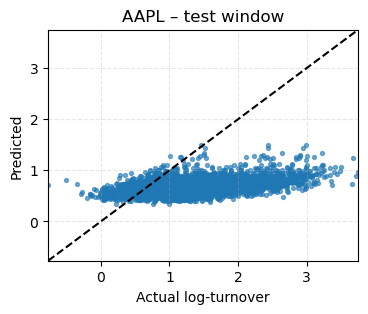


Out-of-sample R² on log-turnover (bn USD)

AAPL  |  SCNN R² = -0.843   |  AR(1) R² =  0.187
MSFT  |  SCNN R² = -0.951   |  AR(1) R² =  0.187
GOOG  |  SCNN R² = -1.089   |  AR(1) R² =  0.187


In [3]:
# rich_turnover_scnn_diagnostics.py  ──────────────────────────────────
from __future__ import annotations
import math, numpy as np, pandas as pd, yfinance as yf
import pandas_market_calendars as mcal, matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scnn.optimize import optimize
from scnn.regularizers import NeuronGL1

# ─── configuration ───────────────────────────────────────────────────
TICKERS      = ["AAPL", "MSFT", "GOOG"]
START, END   = "2005-01-03", "2022-01-01"
SPLIT_DATE   = "2018-01-02"
AR_LAGS      = 10
MAX_NEURONS  = 800
LAM_GL1      = 1e-3

# ─── fast helpers ────────────────────────────────────────────────────
def dl(tkr: str):
    return yf.download(tkr, start=START, end=END,
                       progress=False, auto_adjust=False)

def parkinson_sigma(df: pd.DataFrame):
    hl = (np.log(df["High"] / df["Low"])) ** 2
    return np.sqrt(hl.rolling(2).sum() / (4 * math.log(2)))

def option_expiry(idx: pd.DatetimeIndex):
    out = pd.Series(False, index=idx)
    out.loc[idx.intersection(pd.date_range(idx.min(), idx.max(),
                                           freq="WOM-3FRI"))] = True
    return out

def build_Xy(df: pd.DataFrame, vix: pd.Series, spyvol: pd.Series,
             t_id: int):
    df = df.copy()
    df["log_ret"]  = np.log(df["Adj Close"]).diff()
    df["turn_bn"]  = df["Adj Close"] * df["Volume"] / 1e9
    df["log_turn"] = np.log(df["turn_bn"]).replace(-np.inf, np.nan)

    # AR lags
    for k in range(1, AR_LAGS + 1):
        df[f"lag_turn_{k}"] = df["log_turn"].shift(k)

    # volatility & price-move features
    df["sigma_hl"] = parkinson_sigma(df) * np.sqrt(252)
    df["abs_ret"]  = df["log_ret"].abs()
    df["sign_ret"] = df["log_ret"]

    # calendar dummies
    df["dow"] = df.index.dayofweek
    for d in range(5):
        df[f"dow_{d}"] = (df["dow"] == d).astype(int)
    nyse  = mcal.get_calendar("NYSE")
    sched = nyse.schedule(df.index.min(), df.index.max())
    eom   = sched.index.to_series()\
            .groupby(sched.index.to_period("M")).last()
    df["month_end"] = df.index.isin(eom.values).astype(int)
    df["opt_exp"]   = option_expiry(df.index).astype(int)

    # market-wide drivers (lag-1)
    df["vix_lag1"]    = vix.shift(1)
    df["spyvol_lag1"] = spyvol.shift(1)

    df["ticker_id"] = t_id

    y = df["log_turn"].shift(-1)                 # target = next-day turn
    X = df.drop(columns=[
        "turn_bn", "log_turn", "log_ret",
        "Volume", "Adj Close", "Close",
        "High", "Low", "Open", "dow"
    ])

    return X.dropna(), y.loc[X.index]

# ─── 1.  build pooled dataset ────────────────────────────────────────
vix    = dl("^VIX")["Adj Close"].pct_change()
spyvol = dl("SPY")["Volume"] / 1e9

Xs, ys = [], []
for i, tkr in enumerate(TICKERS):
    Xi, yi = build_Xy(dl(tkr), vix, spyvol, i)
    Xs.append(Xi);  ys.append(yi)

X_all = pd.concat(Xs).sort_index()
y_all = pd.concat(ys).sort_index()
common = X_all.index.intersection(y_all.index)
X_all, y_all = X_all.loc[common], y_all.loc[common]

mask_train = X_all.index < SPLIT_DATE
X_tr = X_all[mask_train].to_numpy(np.float32)
y_tr = y_all[mask_train].to_numpy(np.float32).reshape(-1, 1)
X_te = X_all[~mask_train].to_numpy(np.float32)
y_te = y_all[~mask_train].to_numpy(np.float32).reshape(-1, 1)

# ─── 2.  pooled SCNN training ────────────────────────────────────────
model, _ = optimize(
    formulation="gated_relu",
    max_neurons=MAX_NEURONS,
    X_train=X_tr, y_train=y_tr,
    X_test=X_te,  y_test=y_te,
    loss_type="huber", huber_delta=1.0,
    regularizer=NeuronGL1(LAM_GL1),
    verbose=True, device="cpu",
)

# predictions in test-set order
pred_vec = model(X_te).ravel()

# helper frame, index ≡ test rows
df_pred = X_all.loc[~mask_train, ["ticker_id"]].copy()
df_pred["pred_scnn"] = pred_vec        # same length, same order

# ─── 3. diagnostics ──────────────────────────────────────────────────
print("\n--- alignment check (first 3 test rows) ---")
print(pd.concat(
    [
        y_all.loc[df_pred.index].head(3).rename("y_test"),
        X_all.loc[df_pred.index, "lag_turn_1"].head(3).rename("lag_turn_1"),
    ], axis=1))

# Scatter for AAPL
sel = df_pred["ticker_id"].eq(0)
pair = pd.concat(
    [
        y_all.loc[df_pred.index[sel]].rename("y"),
        df_pred.loc[sel, "pred_scnn"].rename("pred"),
    ],
    axis=1,
).dropna()
plt.figure(figsize=(4, 3))
plt.scatter(pair["y"], pair["pred"], s=8, alpha=0.6)
lims = [pair.min().min(), pair.max().max()]
plt.plot(lims, lims, "k--"); plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual log-turnover"); plt.ylabel("Predicted")
plt.title("AAPL – test window"); plt.grid(True, ls="--", alpha=.3)
plt.show()

# ─── 4.  per-ticker OOS R²   (SCNN vs AR-1) ──────────────────────────
print("\nOut-of-sample R² on log-turnover (bn USD)\n")
table = []
for i, tkr in enumerate(TICKERS):
    sel = df_pred["ticker_id"].eq(i)
    df_tkr = pd.concat(
        [
            y_all.loc[df_pred.index[sel]].rename("y"),
            X_all.loc[df_pred.index[sel], "lag_turn_1"].rename("x1"),
            df_pred.loc[sel, "pred_scnn"].rename("pred"),
        ],
        axis=1,
    ).dropna()

    if len(df_tkr) < 2:
        print(f"{tkr}: too few test points → R² = NaN")
        continue

    # SCNN R²
    r2_scnn = r2_score(df_tkr["y"], df_tkr["pred"])

    # AR(1) baseline
    lr = LinearRegression().fit(df_tkr[["x1"]].values, df_tkr["y"].values)
    r2_ar1 = lr.score(df_tkr[["x1"]].values, df_tkr["y"].values)

    table.append([tkr, r2_scnn, r2_ar1])
    print(f"{tkr:5s} |  SCNN R² = {r2_scnn:6.3f}   |  AR(1) R² = {r2_ar1:6.3f}")

# pretty table if you need it later
# res_df = pd.DataFrame(table, columns=["Ticker","SCNN_R2","AR1_R2"]).set_index("Ticker")


Training pooled SCNN …

Out-of-sample R²  (pooled SCNN vs AR(1))
AAPL  |  SCNN R² = -0.848  |  AR(1) R² =  0.187
MSFT  |  SCNN R² = -0.955  |  AR(1) R² =  0.187
GOOG  |  SCNN R² = -1.092  |  AR(1) R² =  0.187

─ Per-ticker, z-scaled SCNNs ─
AAPL  |  SCNN R² = -1.332  |  AR(1) R² = -0.639
MSFT  |  SCNN R² = -0.682  |  AR(1) R² = -0.300
GOOG  |  SCNN R² = -1.319  |  AR(1) R² = -0.745


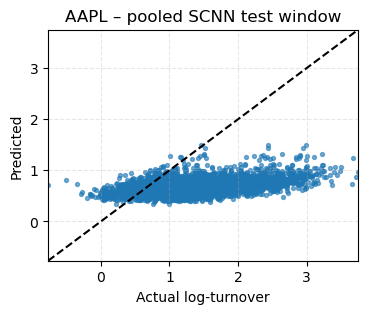

In [1]:
# rich_turnover_scnn_full.py  ─────────────────────────────────────────
from __future__ import annotations
import math, numpy as np, pandas as pd, yfinance as yf
import pandas_market_calendars as mcal, matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from copy import deepcopy

from scnn.optimize import optimize
from scnn.regularizers import NeuronGL1

# ─── configuration ──────────────────────────────────────────────────
TICKERS      = ["AAPL", "MSFT", "GOOG"]
START, END   = "2005-01-03", "2022-01-01"
SPLIT_DATE   = "2018-01-02"
AR_LAGS      = 10
MAX_NEURONS  = 800        # pooled model
LAM_GL1      = 1e-3
# per-ticker hyper-params
PT_NEURONS   = 1500
PT_LAM       = 1e-4

# ─── fast helpers ────────────────────────────────────────────────────
def dl(tkr: str):
    return yf.download(tkr, start=START, end=END,
                       progress=False, auto_adjust=False)

def parkinson_sigma(df: pd.DataFrame):
    hl = (np.log(df["High"] / df["Low"])) ** 2
    return np.sqrt(hl.rolling(2).sum() / (4 * math.log(2)))

def option_expiry(idx: pd.DatetimeIndex):
    out = pd.Series(False, index=idx)
    out.loc[idx.intersection(pd.date_range(idx.min(), idx.max(),
                                           freq="WOM-3FRI"))] = True
    return out

def build_Xy(df: pd.DataFrame, vix: pd.Series, spyvol: pd.Series,
             t_id: int):
    """Return (X,y) with next-day log-turnover target."""
    df = df.copy()
    df["log_ret"]  = np.log(df["Adj Close"]).diff()
    df["turn_bn"]  = df["Adj Close"] * df["Volume"] / 1e9
    df["log_turn"] = np.log(df["turn_bn"]).replace(-np.inf, np.nan)

    # AR lags of log_turn
    for k in range(1, AR_LAGS + 1):
        df[f"lag_turn_{k}"] = df["log_turn"].shift(k)

    # volatility & price-action features
    df["sigma_hl"] = parkinson_sigma(df) * np.sqrt(252)
    df["abs_ret"]  = df["log_ret"].abs()
    df["sign_ret"] = df["log_ret"]

    # calendar dummies
    df["dow"] = df.index.dayofweek
    for d in range(5):
        df[f"dow_{d}"] = (df["dow"] == d).astype(int)
    nyse  = mcal.get_calendar("NYSE")
    sched = nyse.schedule(df.index.min(), df.index.max())
    eom   = sched.index.to_series().groupby(
        sched.index.to_period("M")).last()
    df["month_end"] = df.index.isin(eom.values).astype(int)
    df["opt_exp"]   = option_expiry(df.index).astype(int)

    # market drivers, lag-1
    df["vix_lag1"]    = vix.shift(1)
    df["spyvol_lag1"] = spyvol.shift(1)

    df["ticker_id"] = t_id

    y = df["log_turn"].shift(-1)                 # next-day target
    X = df.drop(columns=[
        "turn_bn", "log_turn", "log_ret",
        "Volume", "Adj Close", "Close",
        "High", "Low", "Open", "dow"
    ])

    return X.dropna(), y.loc[X.index]

# ─── 1. pooled dataset ───────────────────────────────────────────────
vix    = dl("^VIX")["Adj Close"].pct_change()
spyvol = dl("SPY")["Volume"] / 1e9

Xs, ys = [], []
for i, tkr in enumerate(TICKERS):
    Xi, yi = build_Xy(dl(tkr), vix, spyvol, i)
    Xs.append(Xi);  ys.append(yi)

X_all = pd.concat(Xs).sort_index()
y_all = pd.concat(ys).sort_index()
common = X_all.index.intersection(y_all.index)
X_all, y_all = X_all.loc[common], y_all.loc[common]

mask_train = X_all.index < SPLIT_DATE
X_tr = X_all[mask_train].to_numpy(np.float32)
y_tr = y_all[mask_train].to_numpy(np.float32).reshape(-1, 1)
X_te = X_all[~mask_train].to_numpy(np.float32)
y_te = y_all[~mask_train].to_numpy(np.float32).reshape(-1, 1)

# ─── 2. pooled SCNN ──────────────────────────────────────────────────
print("\nTraining pooled SCNN …")
model, _ = optimize(
    formulation="gated_relu",
    max_neurons=MAX_NEURONS,
    X_train=X_tr, y_train=y_tr,
    X_test=X_te,  y_test=y_te,
    loss_type="huber", huber_delta=1.0,
    regularizer=NeuronGL1(LAM_GL1),
    verbose=False, device="cpu",
)

pred_vec = model(X_te).ravel()
df_pred = X_all.loc[~mask_train, ["ticker_id"]].copy()
df_pred["pred_scnn"] = pred_vec        # same length & order

# ─── 3. pooled R² vs AR(1) baseline ──────────────────────────────────
print("\nOut-of-sample R²  (pooled SCNN vs AR(1))")
tbl = []
for i, tkr in enumerate(TICKERS):
    sel = df_pred["ticker_id"].eq(i)
    df_tkr = pd.concat(
        [
            y_all.loc[df_pred.index[sel]].rename("y"),
            X_all.loc[df_pred.index[sel], "lag_turn_1"].rename("x1"),
            df_pred.loc[sel, "pred_scnn"].rename("pred"),
        ],
        axis=1,
    ).dropna()
    if len(df_tkr) < 2:
        print(f"{tkr}: too few pts → NaN");  continue
    r2_scnn = r2_score(df_tkr["y"], df_tkr["pred"])
    lr      = LinearRegression().fit(df_tkr[["x1"]], df_tkr["y"])
    r2_ar1  = lr.score(df_tkr[["x1"]], df_tkr["y"])
    tbl.append([tkr, r2_scnn, r2_ar1])
    print(f"{tkr:5s} |  SCNN R² = {r2_scnn:6.3f}  |  AR(1) R² = {r2_ar1:6.3f}")

# ─── 4. per-ticker, z-scaled SCNNs ───────────────────────────────────
def per_stock_scnn(tkr_id: int,
                   lam=PT_LAM, neurons=PT_NEURONS) -> tuple[str,float,float]:
    tkr = TICKERS[tkr_id]
    rows_tr = X_all["ticker_id"].eq(tkr_id) & (X_all.index < SPLIT_DATE) & ~y_all.isna()
    rows_te = X_all["ticker_id"].eq(tkr_id) & (X_all.index >= SPLIT_DATE) & ~y_all.isna()

    Xtr_raw, Xte_raw = X_all.loc[rows_tr], X_all.loc[rows_te]
    ytr_raw, yte_raw = y_all.loc[rows_tr], y_all.loc[rows_te]

    float_cols = Xtr_raw.select_dtypes("float").columns
    sc = StandardScaler().fit(Xtr_raw[float_cols])
    Xtr = deepcopy(Xtr_raw);  Xte = deepcopy(Xte_raw)
    Xtr[float_cols] = sc.transform(Xtr_raw[float_cols])
    Xte[float_cols] = sc.transform(Xte_raw[float_cols])

    mdl,_ = optimize("gated_relu", neurons,
                     Xtr.to_numpy(np.float32),
                     ytr_raw.to_numpy(np.float32).reshape(-1,1),
                     Xte.to_numpy(np.float32),
                     yte_raw.to_numpy(np.float32).reshape(-1,1),
                     loss_type="least squares",
                     regularizer=NeuronGL1(lam),
                     verbose=False, device="cpu")
    y_pred = mdl(Xte.to_numpy(np.float32)).ravel()
    r2_scn = r2_score(yte_raw, y_pred)

    lr = LinearRegression().fit(Xtr[["lag_turn_1"]], ytr_raw)
    r2_ar = lr.score(Xte[["lag_turn_1"]], yte_raw)
    return tkr, r2_scn, r2_ar

print("\n─ Per-ticker, z-scaled SCNNs ─")
for i in range(len(TICKERS)):
    tkr, r2_scn, r2_ar = per_stock_scnn(i)
    print(f"{tkr:5s} |  SCNN R² = {r2_scn:6.3f}  |  AR(1) R² = {r2_ar:6.3f}")

# ─── 5. quick scatter (AAPL) ─────────────────────────────────────────
sel = df_pred["ticker_id"].eq(0)
pair = pd.concat(
    [
        y_all.loc[df_pred.index[sel]].rename("y"),
        df_pred.loc[sel, "pred_scnn"].rename("pred"),
    ],
    axis=1,
).dropna()

plt.figure(figsize=(4,3))
plt.scatter(pair["y"], pair["pred"], s=8, alpha=0.6)
lims=[pair.min().min(), pair.max().max()]
plt.plot(lims, lims, "k--"); plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual log-turnover"); plt.ylabel("Predicted")
plt.title("AAPL – pooled SCNN test window")
plt.grid(True, ls="--", alpha=.3);  plt.show()